In [225]:
import numpy as np

In [226]:
from sklearn.datasets import make_moons

In [227]:
def initialize_parameters(layer_dims):
    parameters = {}
    L = len(layer_dims)
    for l in range(1, L):
        parameters['W' + str(l)] = np.random.randn(layer_dims[l], layer_dims[l - 1]) * np.sqrt(2 / layer_dims[l - 1])
        parameters['b' + str(l)] = np.zeros((layer_dims[l], 1))
    return parameters

In [228]:
def initialize_momentum(layer_dims, parameters):
    v = {}
    L = len(parameters) // 2
    for l in range(1, L + 1):
        v['dW' + str(l)] = np.zeros_like(parameters['W' + str(l)])
        v['db' + str(l)] = np.zeros_like(parameters['b' + str(l)])
    return v

In [229]:
def momentum(parameters, grads, v, beta, learning_rate, layer_dims):
    L = len(parameters) // 2
    for l in range(1, L + 1):
        v['dW' + str(l)] = v['dW' + str(l)] * beta + (1 - beta)*grads['dW' + str(l)]
        v['db' + str(l)] = v['db' + str(l)] * beta + (1 - beta)*grads['db' + str(l)]

        parameters['W' + str(l)] = parameters['W' + str(l)] - learning_rate * v['dW' + str(l)]
        parameters['b' + str(l)] = parameters['b' + str(l)] - learning_rate * v['db' + str(l)]
    return parameters, v

In [230]:
def initialize_RMSProp(layer_dims, parameters):
    s = {}
    L = len(parameters) // 2
    for l in range(1, L + 1):
        s['dW' + str(l)] = np.zeros_like(parameters['W' + str(l)])
        s['db' + str(l)] = np.zeros_like(parameters['b' + str(l)])
    return s

In [231]:
def RMSProp(layer_dims, parameters, beta, learning_rate, grads, s, epsilon = 10e-8):
    L = len(parameters) // 2
    for l in range(1, L + 1):
        s['dW' + str(l)] = s['dW' + str(l)] * beta + (1 - beta) * np.square(grads['dW' + str(l)])
        s['db' + str(l)] = s['db' + str(l)] * beta + (1 - beta) * np.square(grads['db' + str(l)])

        parameters['W' + str(l)] = parameters['W' + str(l)] - learning_rate*(grads['dW' + str(l)])/((np.sqrt(s['dW' + str(l)])) + epsilon)
        parameters['b' + str(l)] = parameters['b' + str(l)] - learning_rate*(grads['db' + str(l)])/((np.sqrt(s['db' + str(l)])) + epsilon)
    return parameters, s

In [232]:
def initialize_Adam(layer_dims, parameters):
    v = {}
    s = {}
    L = len(parameters) // 2
    for l in range(1, L + 1):
        v['dW' + str(l)] = np.zeros_like(parameters['W' + str(l)])
        v['db' + str(l)] = np.zeros_like(parameters['b' + str(l)])
        s['dW' + str(l)] = np.zeros_like(parameters['W' + str(l)])
        s['db' + str(l)] = np.zeros_like(parameters['b' + str(l)])
    return v, s


In [233]:
def Adam(layer_dims, beta1, beta2, parameters, grads, v, s, t, leearning_rate, epsilon = 10e-8):
    L = len(parameters) // 2
    v_corrected = {}
    s_corrected = {}
    for l in range(1, L + 1):
        v['dW' + str(l)] = beta1*v['dW' + str(l)] + (1 - beta1)*grads['dW' + str(l)]
        v['db' + str(l)] = beta1*v['db' + str(l)] + (1 - beta1)*grads['db' + str(l)]
        s['dW' + str(l)] = beta2*s['dW' + str(l)] + (1 - beta2)*np.square(grads['dW' + str(l)])
        s['db' + str(l)] = beta2*s['db' + str(l)] + (1 - beta2)*np.square(grads['db' + str(l)])

        v_corrected['dW' + str(l)] = v['dW' + str(l)] / (1 - beta1**t)
        v_corrected['db' + str(l)] = v['db' + str(l)] / (1 - beta1**t)
        s_corrected['dW' + str(l)] = s['dW' + str(l)] / (1 - beta2**t)
        s_corrected['db' + str(l)] = s['db' + str(l)] / (1 - beta2**t)
    
        parameters['W' + str(l)] -= leearning_rate*(v_corrected['dW' + str(l)] / (np.sqrt(s_corrected['dW' + str(l)]) + epsilon))
        parameters['b' + str(l)] -= leearning_rate*(v_corrected['db' + str(l)] / (np.sqrt(s_corrected['db' + str(l)]) + epsilon))

    return parameters, v, s

In [234]:
def relu(Z):
    return np.maximum(0, Z)

In [235]:
def sigmoid(Z):
    return np.where(
        Z >= 0,
        1 / (1 + np.exp(-Z)),
        np.exp(Z) / (1 + np.exp(Z))
    )

In [236]:
def forward_pass(X, parameters):
    cache = {}
    cache['A0'] = X
    L = len(parameters) // 2
    for l in range(1, L):
        Z = np.dot(parameters['W' + str(l)], cache['A' + str(l - 1)]) + parameters['b' + str(l)]
        cache['Z' + str(l)] = Z
        cache['A' + str(l)] = relu(Z)
    ZL = np.dot(parameters['W' + str(L)], cache['A' + str(L - 1)]) + parameters['b' + str(L)]
    cache['A' + str(L)] = sigmoid(ZL)
    cache['Z' + str(L)] = ZL
    return cache['A' + str(L)], cache 

In [237]:
def backprop(X, Y, parameters, cache):
    m = Y.shape[1]
    L = len(parameters) // 2
    grads = {}
    dZ = cache['A' + str(L)] - Y
    grads['dW' + str(L)] = (1.0 / m) * np.dot(dZ, cache['A' + str(L-1)].T)
    grads['db' + str(L)] = (1.0 / m) * np.sum(dZ, axis = 1, keepdims = True)
    for l in reversed(range(1, L)):
        dA = np.dot(parameters['W' + str(l + 1)].T, dZ)
        dZ = np.array(dA, copy = True)
        dZ[cache['Z' + str(l)] <= 0] = 0  
        if (l - 1) > 0:
            A_prev = cache['A' + str(l-1)]
        else:
            A_prev = X
        grads['dW' + str(l)] = (1.0 / m) * np.dot(dZ, A_prev.T)
        grads['db' + str(l)] = (1.0 / m) * np.sum(dZ, axis = 1, keepdims = True)
    return grads

In [238]:
def compute_cost(AL, Y):
    m = Y.shape[1]
    AL = np.clip(AL, 1e-15, 1.0 - 1e-15)
    cross_entropy_cost = -(1.0/m) * np.sum(Y * np.log(AL) + (1.0 - Y)*np.log(1.0 - AL))
    return np.squeeze(cross_entropy_cost)

In [239]:
from sklearn.model_selection import train_test_split
X_raw, Y_raw = make_moons(n_samples=500, noise=0.2, random_state=42)
X_train_raw, X_test_raw, Y_train_raw, Y_test_raw = train_test_split(X_raw, Y_raw, test_size = 0.2, random_state = 42)
X_train = X_train_raw.T
X_test = X_test_raw.T
Y_train = Y_train_raw.reshape(1, -1)
Y_test = Y_test_raw.reshape(1, -1)
print(f'Train Set Shapes - X: {X_train.shape}, Y: {Y_train.shape}')
print(f'Test Set Shapes - X: {X_test.shape}, Y: {Y_test.shape}')

Train Set Shapes - X: (2, 400), Y: (1, 400)
Test Set Shapes - X: (2, 100), Y: (1, 100)


In [240]:
def model(X, Y, layer_dims, optimizer, learning_rate = 0.075, iter = 3000, beta1 = 0.9, beta2 = 0.999, epsilon = 10e-8):
    costs = []
    t = 0

    parameters = initialize_parameters(layer_dims)

    if optimizer == 'momentum':
        v = initialize_momentum(layer_dims, parameters)
    elif optimizer == 'RMSProp':
        s = initialize_RMSProp(layer_dims, parameters)
    elif optimizer == 'Adam':
        v, s = initialize_Adam(layer_dims, parameters)
    
    for i in range(iter):
        AL, cache = forward_pass(X, parameters)
        cost = compute_cost(AL, Y)
        grads = backprop(X, Y, parameters, cache)

        if optimizer == 'momentum':
            parameters, v = momentum(parameters, grads, v,beta1, learning_rate, layer_dims)
        elif optimizer == 'RMSProp':
            parameters, s = RMSProp(layer_dims, parameters, beta1, learning_rate, grads, s, epsilon)
        elif optimizer == 'Adam':
            t += 1
            parameters, v, s = Adam(layer_dims, beta1, beta2, parameters, grads, v ,s, t, learning_rate, epsilon)
        
        if i%100 == 0:
            costs.append(cost)
            print(f'Cost value after iteration {i} is {cost}')


    return parameters, costs

In [248]:
parameters_RMSProp, costs_RMSProp = model(
    X_train, Y_train, layer_dims = [X_train.shape[0], 20, 10, 1], 
    optimizer = 'RMSProp',
    learning_rate=0.1,
    iter=3000, 
)

Cost value after iteration 0 is 0.9554290442591452
Cost value after iteration 100 is 0.10308502837970089
Cost value after iteration 200 is 0.030812939364836655
Cost value after iteration 300 is 0.08633064128121529
Cost value after iteration 400 is 0.021728914700172047
Cost value after iteration 500 is 0.026398541293083635
Cost value after iteration 600 is 0.02124200773871408
Cost value after iteration 700 is 0.02063062613323964
Cost value after iteration 800 is 0.02192038862651551
Cost value after iteration 900 is 0.019533894200381426
Cost value after iteration 1000 is 0.024892691558704633
Cost value after iteration 1100 is 0.018830337768168625
Cost value after iteration 1200 is 0.04782712911114665


/var/folders/77/ldbqc6bx5bv3_x7ylv7nzw340000gn/T/ipykernel_17706/3873936345.py:9: RuntimeWarning: overflow encountered in exp
  1 / (1 + np.exp(-Z)),


Cost value after iteration 1300 is 0.05738654038859667
Cost value after iteration 1400 is 0.03237499126956797
Cost value after iteration 1500 is 0.03628572344782035
Cost value after iteration 1600 is 0.018840713339144152
Cost value after iteration 1700 is 0.017495437168245906
Cost value after iteration 1800 is 0.019914241931703887
Cost value after iteration 1900 is 0.015419427322010983
Cost value after iteration 2000 is 0.02344172766360314
Cost value after iteration 2100 is 0.07988835541418003
Cost value after iteration 2200 is 0.03342547975531761
Cost value after iteration 2300 is 0.021218371408440836
Cost value after iteration 2400 is 0.015475373075864383
Cost value after iteration 2500 is 0.015745413675773107
Cost value after iteration 2600 is 0.018718162064528147
Cost value after iteration 2700 is 0.01983114269112149
Cost value after iteration 2800 is 0.020123586550392782
Cost value after iteration 2900 is 0.021374603349847768


In [249]:
import matplotlib.pyplot as plt

def plot_costs(costs, learning_rate):
    plt.figure(figsize=(10, 5))
    plt.plot(costs, linewidth=2.5, label=f'learning rate = {learning_rate}')
    plt.xlabel("Iters x100", fontsize=12)
    plt.ylabel("Cost", fontsize=12)
    plt.legend(fontsize=11)
    plt.show()

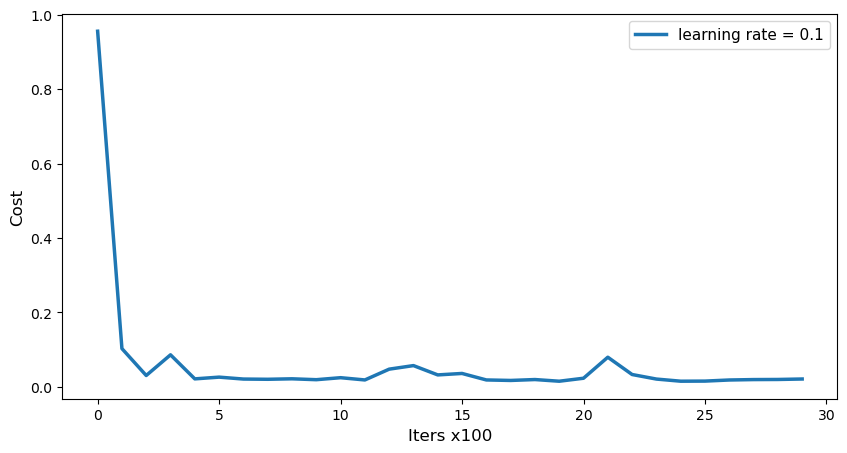

In [250]:
plot_costs(costs_RMSProp, learning_rate=0.1)

In [251]:
parameters_momentum, costs_momentum = model(
    X_train, Y_train, layer_dims = [X_train.shape[0], 20, 10, 1], 
    optimizer = 'momentum',
    learning_rate=0.1,
    iter=3000, 
)

Cost value after iteration 0 is 1.46783326186313
Cost value after iteration 100 is 0.2780692290362052
Cost value after iteration 200 is 0.2582396456673779
Cost value after iteration 300 is 0.24305503470195397
Cost value after iteration 400 is 0.22605542162423206
Cost value after iteration 500 is 0.2054482110338874
Cost value after iteration 600 is 0.1841782777017528
Cost value after iteration 700 is 0.15913048667908664
Cost value after iteration 800 is 0.13461520740977875
Cost value after iteration 900 is 0.11482605622239744
Cost value after iteration 1000 is 0.09706056399461059
Cost value after iteration 1100 is 0.08279285881728055
Cost value after iteration 1200 is 0.07292726925158478
Cost value after iteration 1300 is 0.06569346049011626
Cost value after iteration 1400 is 0.06051985447344364
Cost value after iteration 1500 is 0.05670180367743605
Cost value after iteration 1600 is 0.05374044379011881
Cost value after iteration 1700 is 0.05124474440956536
Cost value after iteration 18

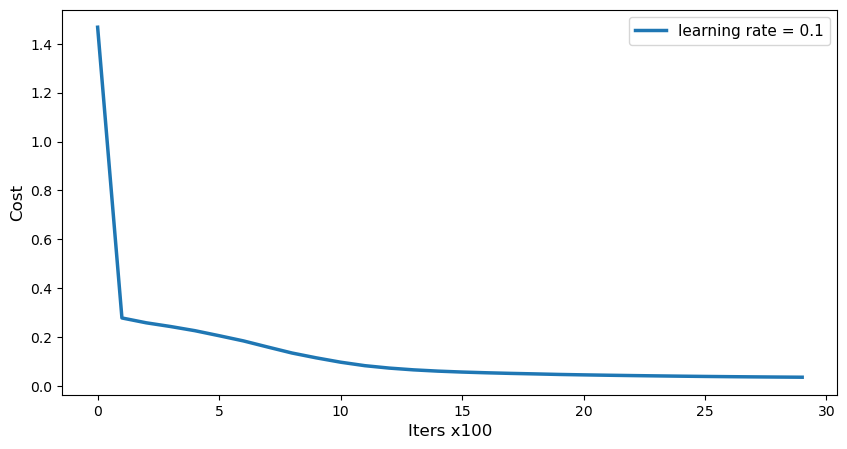

In [252]:
plot_costs(costs_momentum, learning_rate=0.1)

In [253]:
parameters_Adam, costs_Adam = model(
    X_train, Y_train, layer_dims = [X_train.shape[0], 20, 10, 1], 
    optimizer = 'Adam',
    learning_rate=0.1,
    iter=3000, 
)

Cost value after iteration 0 is 1.0930619386212848
Cost value after iteration 100 is 0.02150996726176925
Cost value after iteration 200 is 0.017711502384480046
Cost value after iteration 300 is 0.015739309230224947
Cost value after iteration 400 is 0.013963331954419997
Cost value after iteration 500 is 0.08250967746021769
Cost value after iteration 600 is 0.013242966566035972
Cost value after iteration 700 is 0.01363017624752109
Cost value after iteration 800 is 0.012561026065233306
Cost value after iteration 900 is 0.015711136176317392
Cost value after iteration 1000 is 0.01571908014532224
Cost value after iteration 1100 is 0.014787173392520088
Cost value after iteration 1200 is 0.014558196949833964
Cost value after iteration 1300 is 0.014315577787945353
Cost value after iteration 1400 is 0.009465185977106588
Cost value after iteration 1500 is 0.008144215438975803
Cost value after iteration 1600 is 0.009461045844421869
Cost value after iteration 1700 is 0.00993610127767444
Cost value 

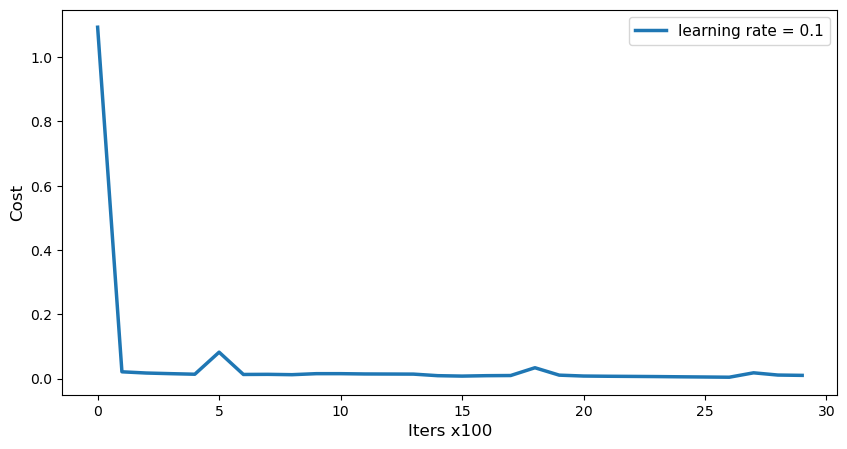

In [255]:
plot_costs(costs_Adam, learning_rate=0.1)